# 📊 Top 10 Stocks Analysis Dashboard

**Comprehensive stock market analysis — Insurance, Finance & Pharmacy sectors**


> **Stocks:** Berkshire Hathaway, Progressive, Allstate, JPMorgan Chase, Goldman Sachs, BlackRock, Pfizer, Johnson & Johnson, Eli Lilly
> **Data:** Yahoo Finance via yfinance | **Period:** 5 Years Daily

---



In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
import warnings
import plotly.io as pio

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
pio.templates.default = "plotly_white"
COLORS = sns.color_palette("husl", 10)

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


---
## 📥 Section 1: Data Collection


In [2]:
STOCKS = {
    'BRK-B': 'Berkshire Hathaway',
    'PGR': 'Progressive',
    'ALL': 'Allstate',
    'JPM': 'JPMorgan Chase',
    'GS': 'Goldman Sachs',
    'BLK': 'BlackRock',
    'PFE': 'Pfizer',
    'JNJ': 'Johnson & Johnson',
    'LLY': 'Eli Lilly',
    'SPY': 'S&P 500 (Benchmark)',
}

RISK_FREE_RATE = 0.045
TRADING_DAYS = 252
ROLLING_WINDOW = 30

tickers = list(STOCKS.keys())
non_spy = [t for t in tickers if t != 'SPY']
print(f"Analyzing {len(non_spy)} stocks + benchmark: {tickers}")
print()
print("⏳ Fetching live data...")
data = yf.download(tickers, period="5y", interval="1d", progress=True)
data.columns = [f'{t}_{col}' for col, t in data.columns]

close = data[[f'{t}_Close' for t in tickers]].copy()
close.columns = tickers
volume = data[[f'{t}_Volume' for t in tickers]].copy()
volume.columns = tickers
high = data[[f'{t}_High' for t in tickers]].copy()
high.columns = tickers
low = data[[f'{t}_Low' for t in tickers]].copy()
low.columns = tickers

close = close.ffill().dropna()
volume = volume.ffill().dropna()

print(f"✓ Fetched {len(data)} days of data")


Analyzing 9 stocks + benchmark: ['NVDA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'AVGO', 'META', 'TSM', 'TSLA', 'SPY']

⏳ Fetching live data...


[*********************100%***********************]  10 of 10 completed

✓ Fetched 1,254 trading days: 2021-09-16 to 2026-09-15


In [3]:
latest_close = close.iloc[-1]
fifty_two_week_high = close.rolling(252).max().iloc[-1]
fifty_two_week_low = close.rolling(252).min().iloc[-1]
avg_volume = volume.mean()

print("="*90)
print("📊 CURRENT MARKET DATA SUMMARY")
print("="*90)
print(f"{'Stock':<25s} {'Price':>10s} {'52W High':>11s} {'52W Low':>11s} {'Avg Vol':>12s}")
print("-" * 80)
for ticker in tickers:
    name = STOCKS[ticker][:23]
    print(f"{name:<25s} ${latest_close[ticker]:>8,.2f} ${fifty_two_week_high[ticker]:>9,.2f} ${fifty_two_week_low[ticker]:>9,.2f} {avg_volume[ticker]:>10,.0f}")


📊 CURRENT MARKET DATA SUMMARY
Stock                          Price    52W High     52W Low      Avg Vol
--------------------------------------------------------------------------------
Nvidia                    $  210.96 $   235.20 $   164.79 368,584,176
Apple                     $  333.08 $   339.79 $   235.83 63,973,197
Alphabet                  $  349.39 $   402.12 $   235.96 32,444,586
Microsoft                 $  505.41 $   537.65 $   352.17 26,880,238
Amazon                    $  253.54 $   284.02 $   198.79 54,536,102
Broadcom                  $  344.72 $   480.81 $   292.95 26,246,443
Meta Platforms            $  665.60 $   777.70 $   525.23 21,719,139
TSMC                      $  418.01 $   477.57 $   258.52 12,864,633
Tesla                     $  358.97 $   489.88 $   298.32 95,307,221
S&P 500 (Benchmark)       $  760.88 $   777.88 $   630.35 74,912,199


---
## 📈 Section 2: Price Performance Analysis


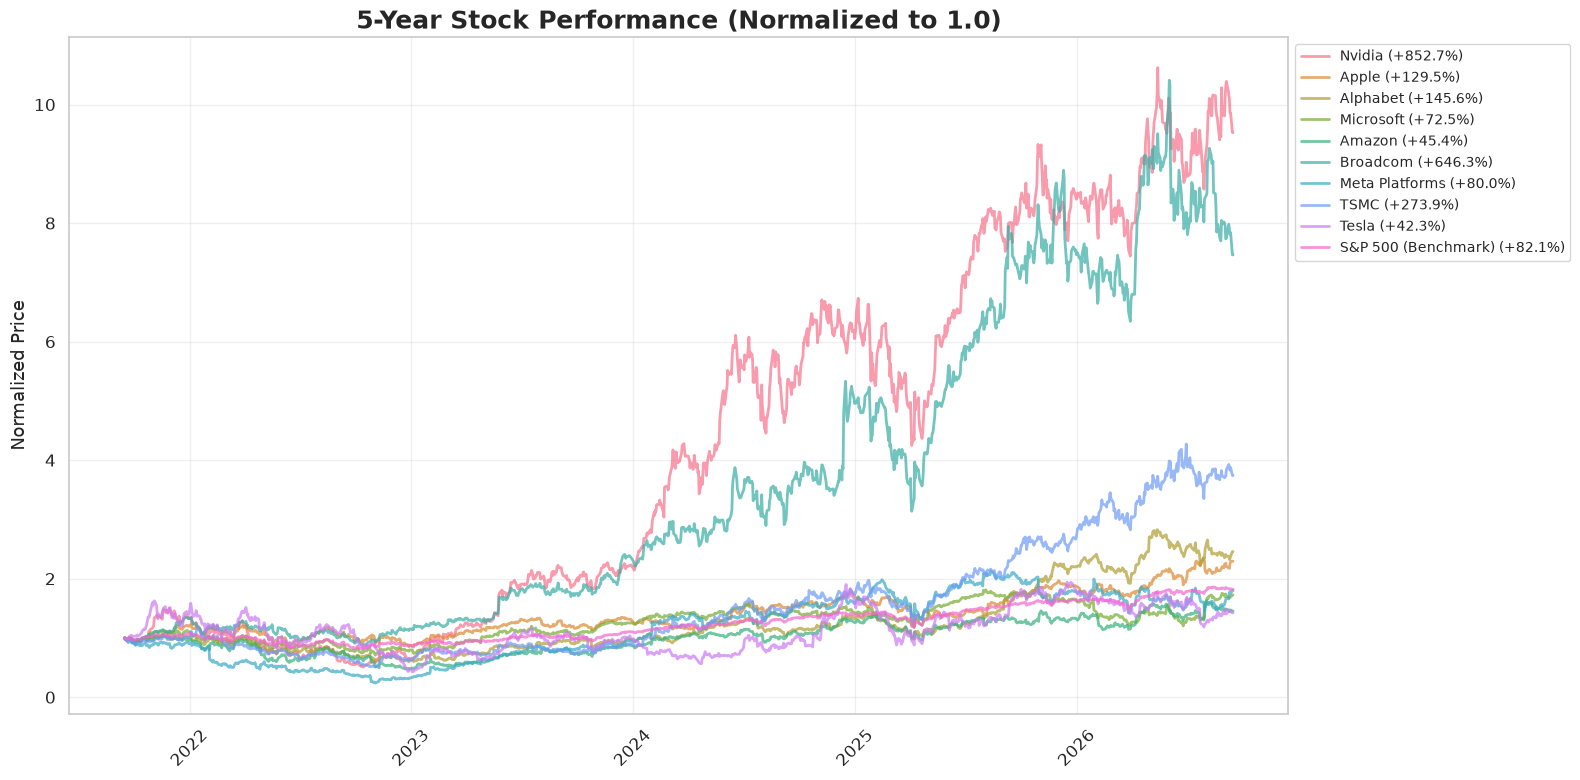

✓ Saved: normalized_price_chart.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))
normalized_prices = close / close.iloc[0]

for i, ticker in enumerate(tickers):
    pct = normalized_prices[ticker].iloc[-1]*100-100
    ax.plot(normalized_prices.index, normalized_prices[ticker],
           label=f"{STOCKS[ticker]} ({pct:+.1f}%)",
           color=COLORS[i], linewidth=2.0, alpha=0.7)

ax.set_title('5-Year Stock Performance (Normalized to 1.0)', fontsize=18, fontweight='bold')
ax.set_ylabel('Normalized Price')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('normalized_price_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: normalized_price_chart.png")


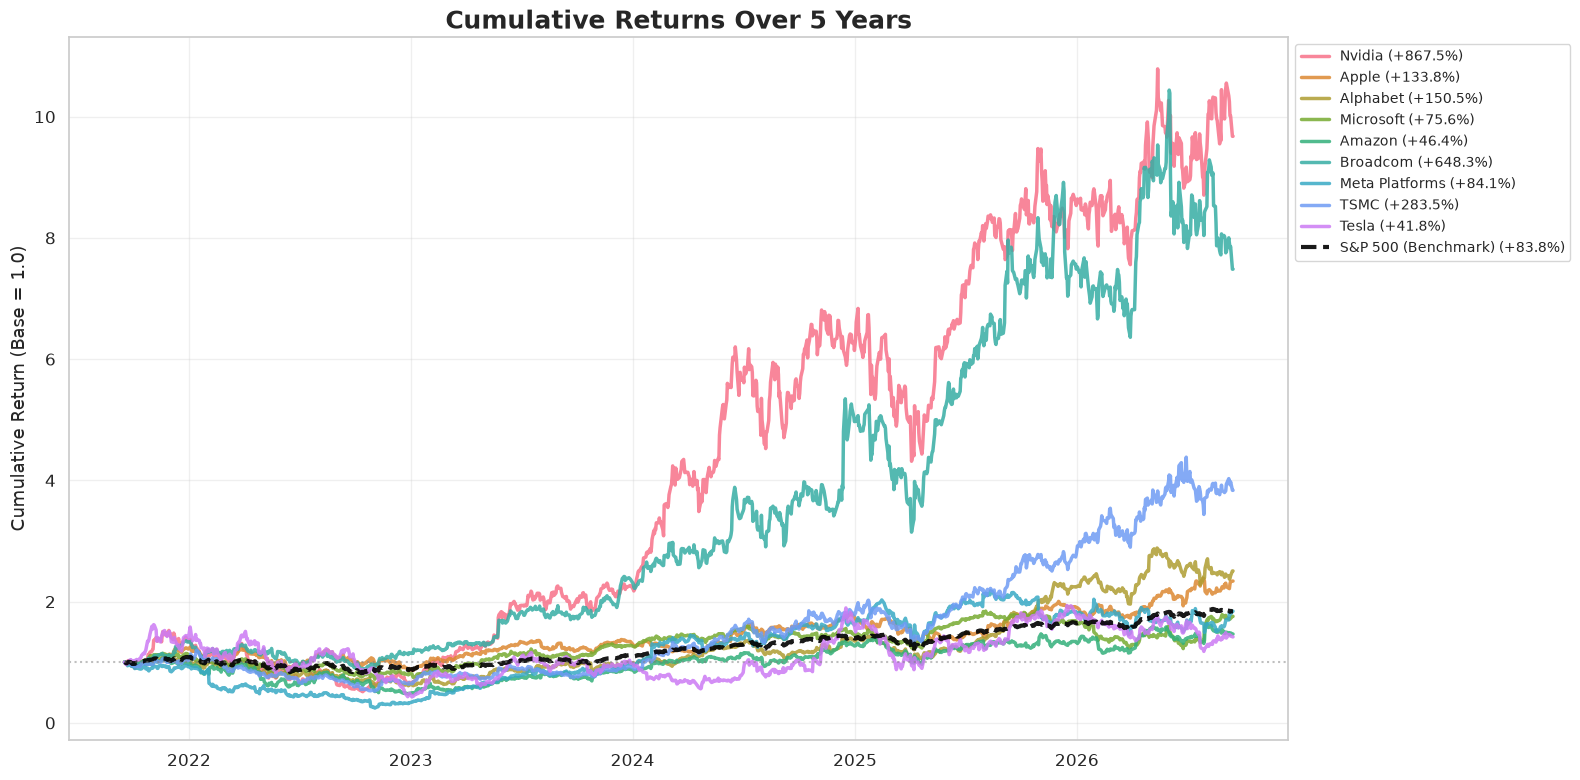

✓ Saved: cumulative_returns_chart.png


In [5]:
daily_returns = close.pct_change().dropna()
cumulative_returns = (1 + daily_returns).cumprod()

fig, ax = plt.subplots(figsize=(16, 8))
cum_normalized = cumulative_returns / cumulative_returns.iloc[0]

for i, ticker in enumerate(non_spy):
    pct = cum_normalized[ticker].iloc[-1]*100-100
    ax.plot(cum_normalized.index, cum_normalized[ticker],
           label=f"{STOCKS[ticker]} ({pct:+.1f}%)",
           color=COLORS[i], linewidth=2.5, alpha=0.85)

pct_spy = cum_normalized['SPY'].iloc[-1]*100-100
ax.plot(cum_normalized.index, cum_normalized['SPY'],
       label=f"{STOCKS['SPY']} ({pct_spy:+.1f}%)",
       color='black', linewidth=3, linestyle='--', alpha=0.9)

ax.set_title('Cumulative Returns Over 5 Years', fontsize=18, fontweight='bold')
ax.set_ylabel('Cumulative Return (Base = 1.0)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('cumulative_returns_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cumulative_returns_chart.png")


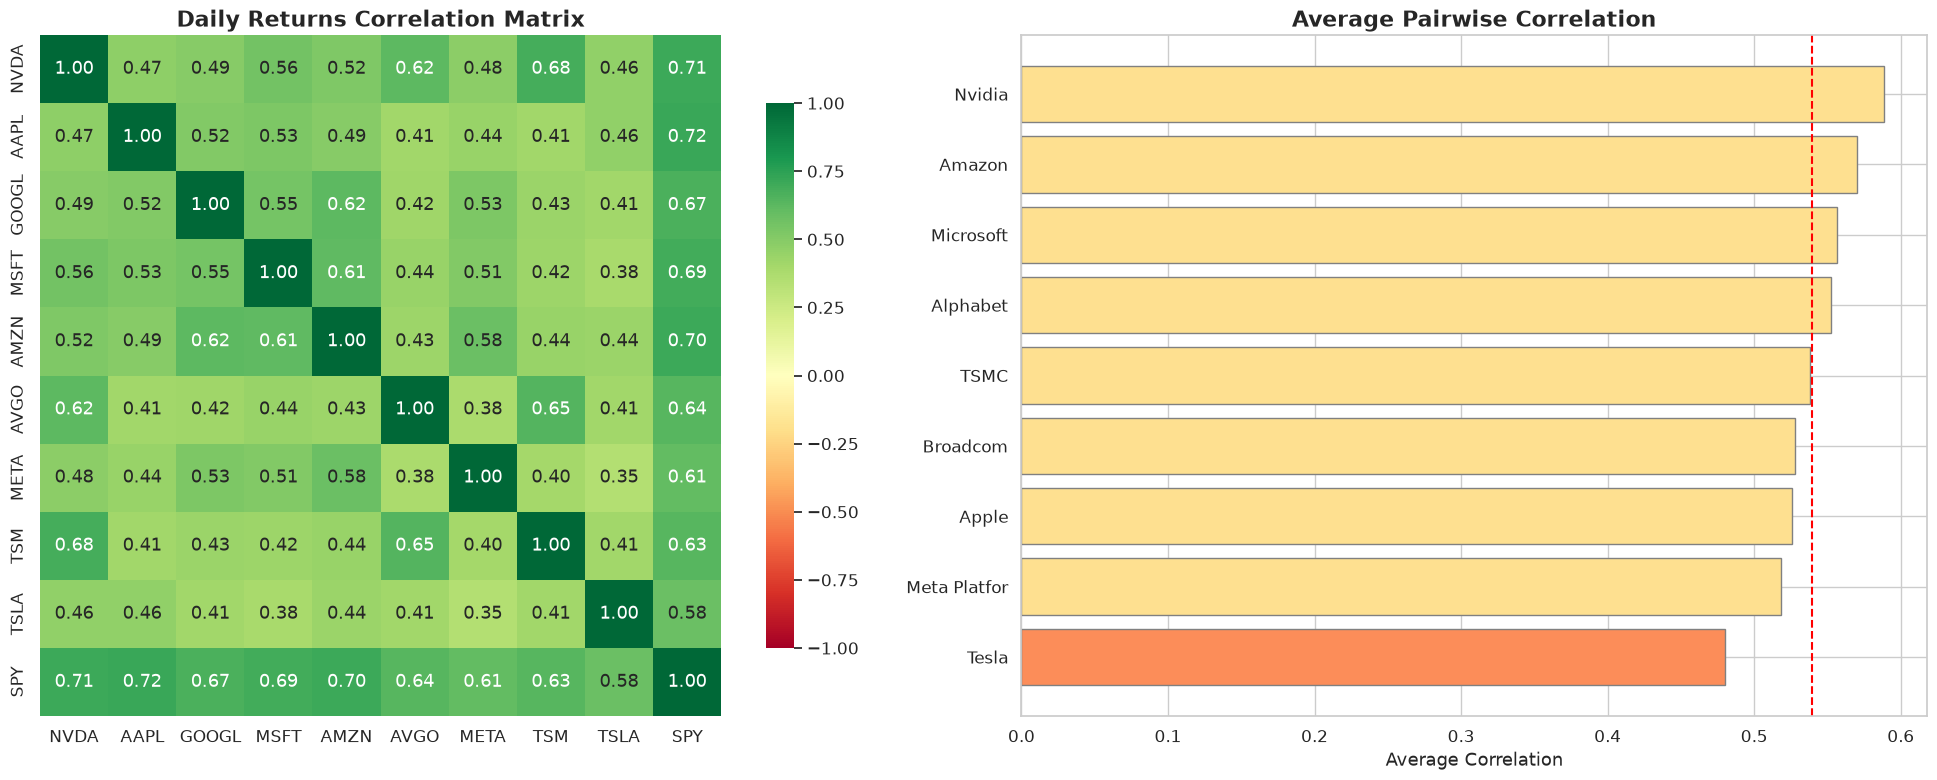

✓ Saved: correlation_heatmap.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
corr_matrix = daily_returns.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Daily Returns Correlation Matrix', fontsize=16, fontweight='bold')

avg_corr = corr_matrix.drop('SPY', axis=0).drop('SPY', axis=1).mean().sort_values(ascending=True)
colors_bar = ['#d73027' if v < 0.3 else '#fc8d59' if v < 0.5 else '#fee090'
              if v < 0.7 else '#e0f3f8' if v < 0.85 else '#91bfdb' for v in avg_corr.values]

axes[1].barh([STOCKS[t][:12] for t in avg_corr.index], avg_corr.values,
            color=colors_bar, edgecolor='gray')
axes[1].set_xlabel('Average Correlation')
axes[1].set_title('Average Pairwise Correlation', fontsize=16, fontweight='bold')
axes[1].axvline(x=avg_corr.mean(), color='red', linestyle='--')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: correlation_heatmap.png")


---
## 📊 Section 3: Returns & Risk Analysis


In [7]:
annualized_returns = daily_returns.mean() * TRADING_DAYS
annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)
sharpe_ratios = (annualized_returns - RISK_FREE_RATE) / annualized_volatility

def calculate_max_drawdown(prices):
    rolling_max = prices.expanding().max()
    drawdown = (prices - rolling_max) / rolling_max
    return drawdown.min()

max_drawdowns = {ticker: calculate_max_drawdown(close[ticker]) for ticker in tickers}

print("="*90)
print("📊 COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*90)
print(f"{'Stock':<25s} {'Price':>9s} {'Ann Ret':>8s} {'Vol':>8s} {'Sharpe':>7s} {'Max DD':>8s}")
print("-" * 75)
for ticker in tickers:
    name = STOCKS[ticker][:23]
    print(f"{name:<25s} ${latest_close[ticker]:>7,.2f} {annualized_returns[ticker]:>7.1%} {annualized_volatility[ticker]:>7.1%} {sharpe_ratios[ticker]:>6.2f} {max_drawdowns[ticker]:>7.1%}")

best_ret = max(non_spy, key=lambda x: annualized_returns[x])
best_sharpe = max(non_spy, key=lambda x: sharpe_ratios[x])
least_vol = min(non_spy, key=lambda x: annualized_volatility[x])
print(f"\n🏆 Best Return: {STOCKS[best_ret]} ({annualized_returns[best_ret]:.1f}%)")
print(f"🏆 Best Risk-Adj: {STOCKS[best_sharpe]} (Sharpe: {sharpe_ratios[best_sharpe]:.2f})")
print(f"🏆 Least Volatile: {STOCKS[least_vol]} ({annualized_volatility[least_vol]:.1f}%)")


📊 COMPREHENSIVE PERFORMANCE SUMMARY
Stock                         Price  Ann Ret      Vol  Sharpe   Max DD
---------------------------------------------------------------------------
Nvidia                    $ 210.96   58.8%   52.1%   1.04  -66.3%
Apple                     $ 333.08   20.6%   28.1%   0.57  -33.4%
Alphabet                  $ 349.39   23.2%   32.2%   0.58  -44.3%
Microsoft                 $ 505.41   14.9%   28.2%   0.37  -37.1%
Amazon                    $ 253.54   14.1%   36.5%   0.26  -55.7%
Broadcom                  $ 344.72   50.2%   44.4%   1.03  -41.1%
Meta Platforms            $ 665.60   22.1%   45.0%   0.39  -76.2%
TSMC                      $ 418.01   33.9%   38.4%   0.76  -56.5%
Tesla                     $ 358.97   25.0%   59.9%   0.34  -73.6%
S&P 500 (Benchmark)       $ 760.88   13.5%   17.2%   0.52  -24.5%

🏆 Best Return: Nvidia (0.6%)
🏆 Best Risk-Adj: Nvidia (Sharpe: 1.04)
🏆 Least Volatile: Apple (0.3%)


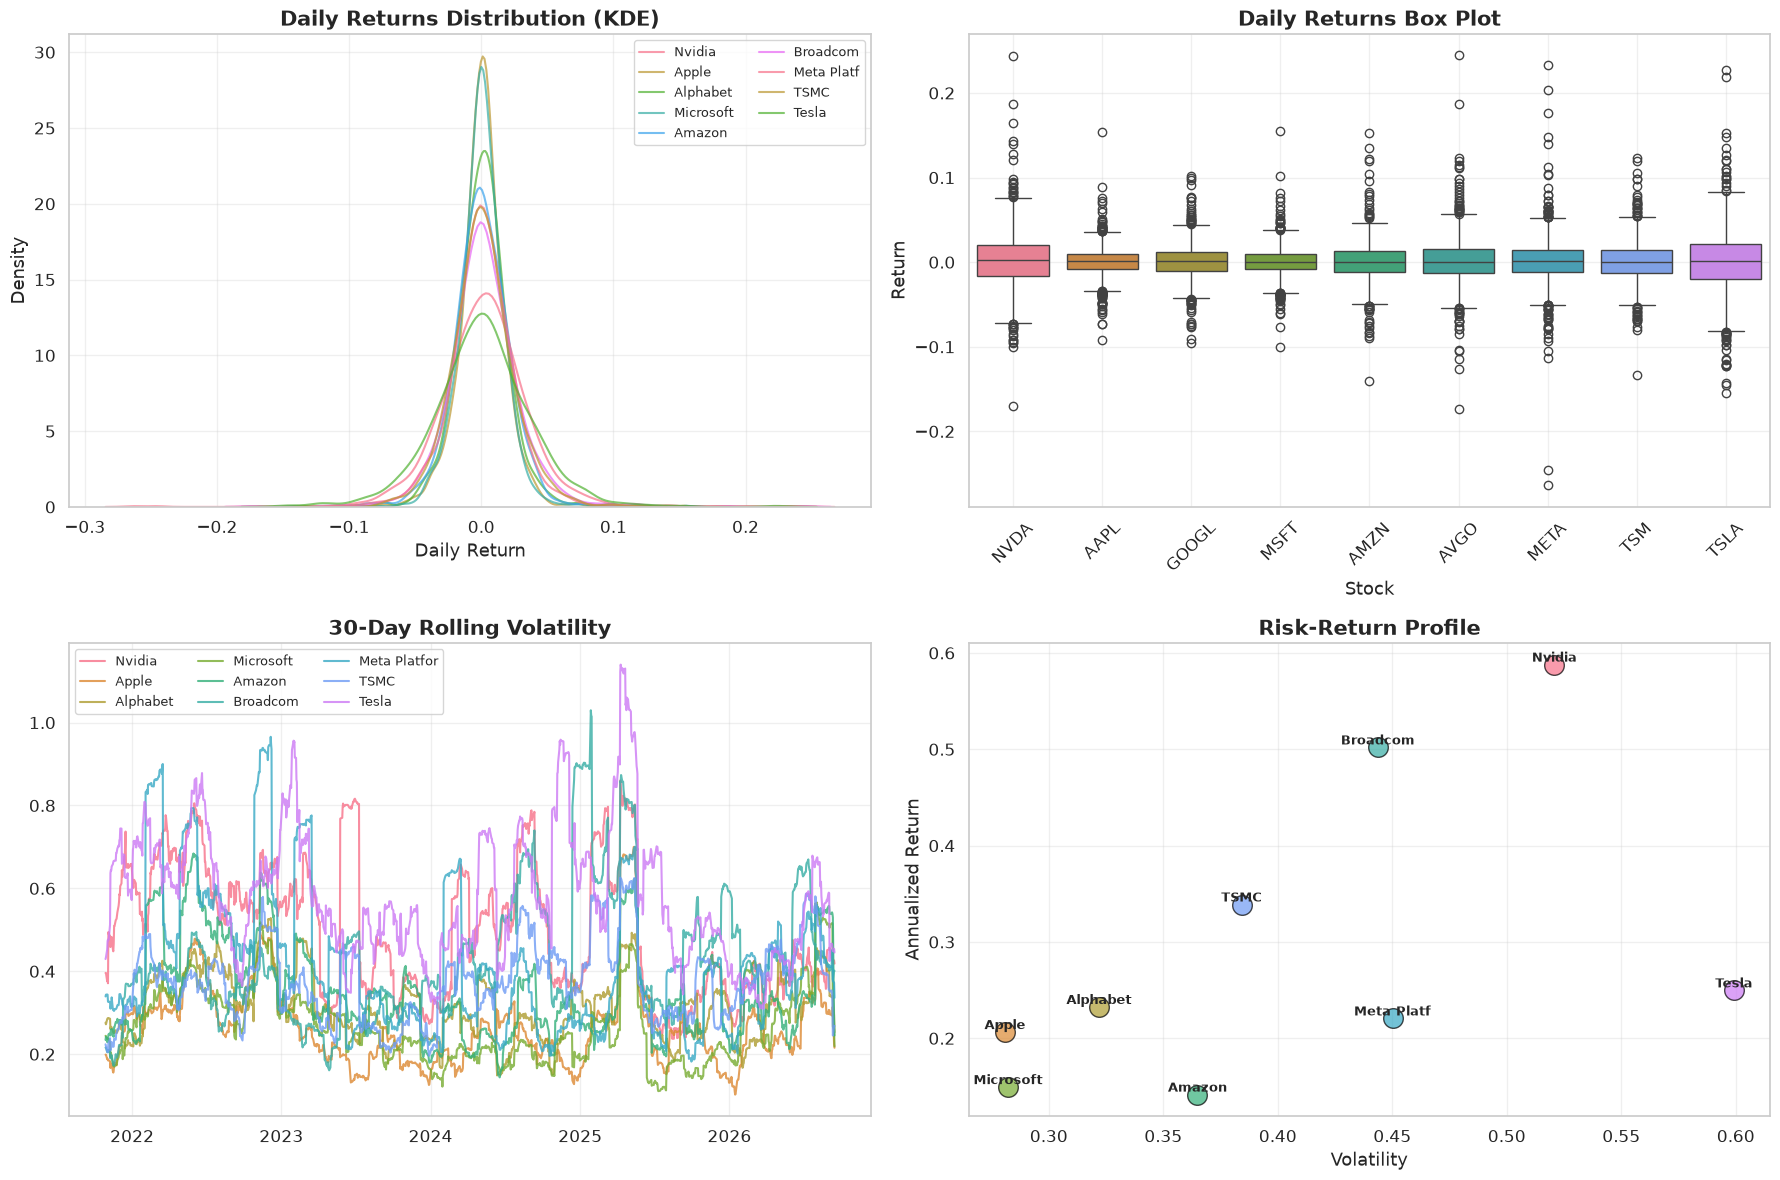

✓ Saved: returns_distribution_analysis.png


In [8]:
# Returns Distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# KDE plot
ax = axes[0, 0]
for i, ticker in enumerate(non_spy):
    sns.kdeplot(daily_returns[ticker], label=STOCKS[ticker][:10], ax=ax, alpha=0.7)
ax.set_title('Daily Returns Distribution (KDE)', fontsize=15, fontweight='bold')
ax.set_xlabel('Daily Return')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# Box plot - FIX: use seaborn instead of pandas boxplot
ax = axes[0, 1]
df_box = daily_returns[non_spy].melt(var_name='Stock', value_name='Return')
sns.boxplot(data=df_box, x='Stock', y='Return', ax=ax, palette=COLORS[:len(non_spy)])
ax.set_title('Daily Returns Box Plot', fontsize=15, fontweight='bold')
ax.set_xlabel('Stock')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Rolling volatility
ax = axes[1, 0]
rolling_vol = daily_returns.rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)
for i, ticker in enumerate(non_spy):
    ax.plot(rolling_vol.index, rolling_vol[ticker], label=STOCKS[ticker][:12], color=COLORS[i], linewidth=1.5, alpha=0.8)
ax.set_title(f'{ROLLING_WINDOW}-Day Rolling Volatility', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

# Risk-Return scatter
ax = axes[1, 1]
for i, ticker in enumerate(non_spy):
    ax.scatter(annualized_volatility[ticker], annualized_returns[ticker],
               s=200, color=COLORS[i], edgecolors='black', alpha=0.7)
    ax.annotate(STOCKS[ticker][:10],
               (annualized_volatility[ticker], annualized_returns[ticker]),
               fontsize=9, ha='center', va='bottom', fontweight='bold')
ax.set_title('Risk-Return Profile', fontsize=15, fontweight='bold')
ax.set_xlabel('Volatility')
ax.set_ylabel('Annualized Return')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('returns_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: returns_distribution_analysis.png")


---
## 🔮 Section 4: Technical Analysis


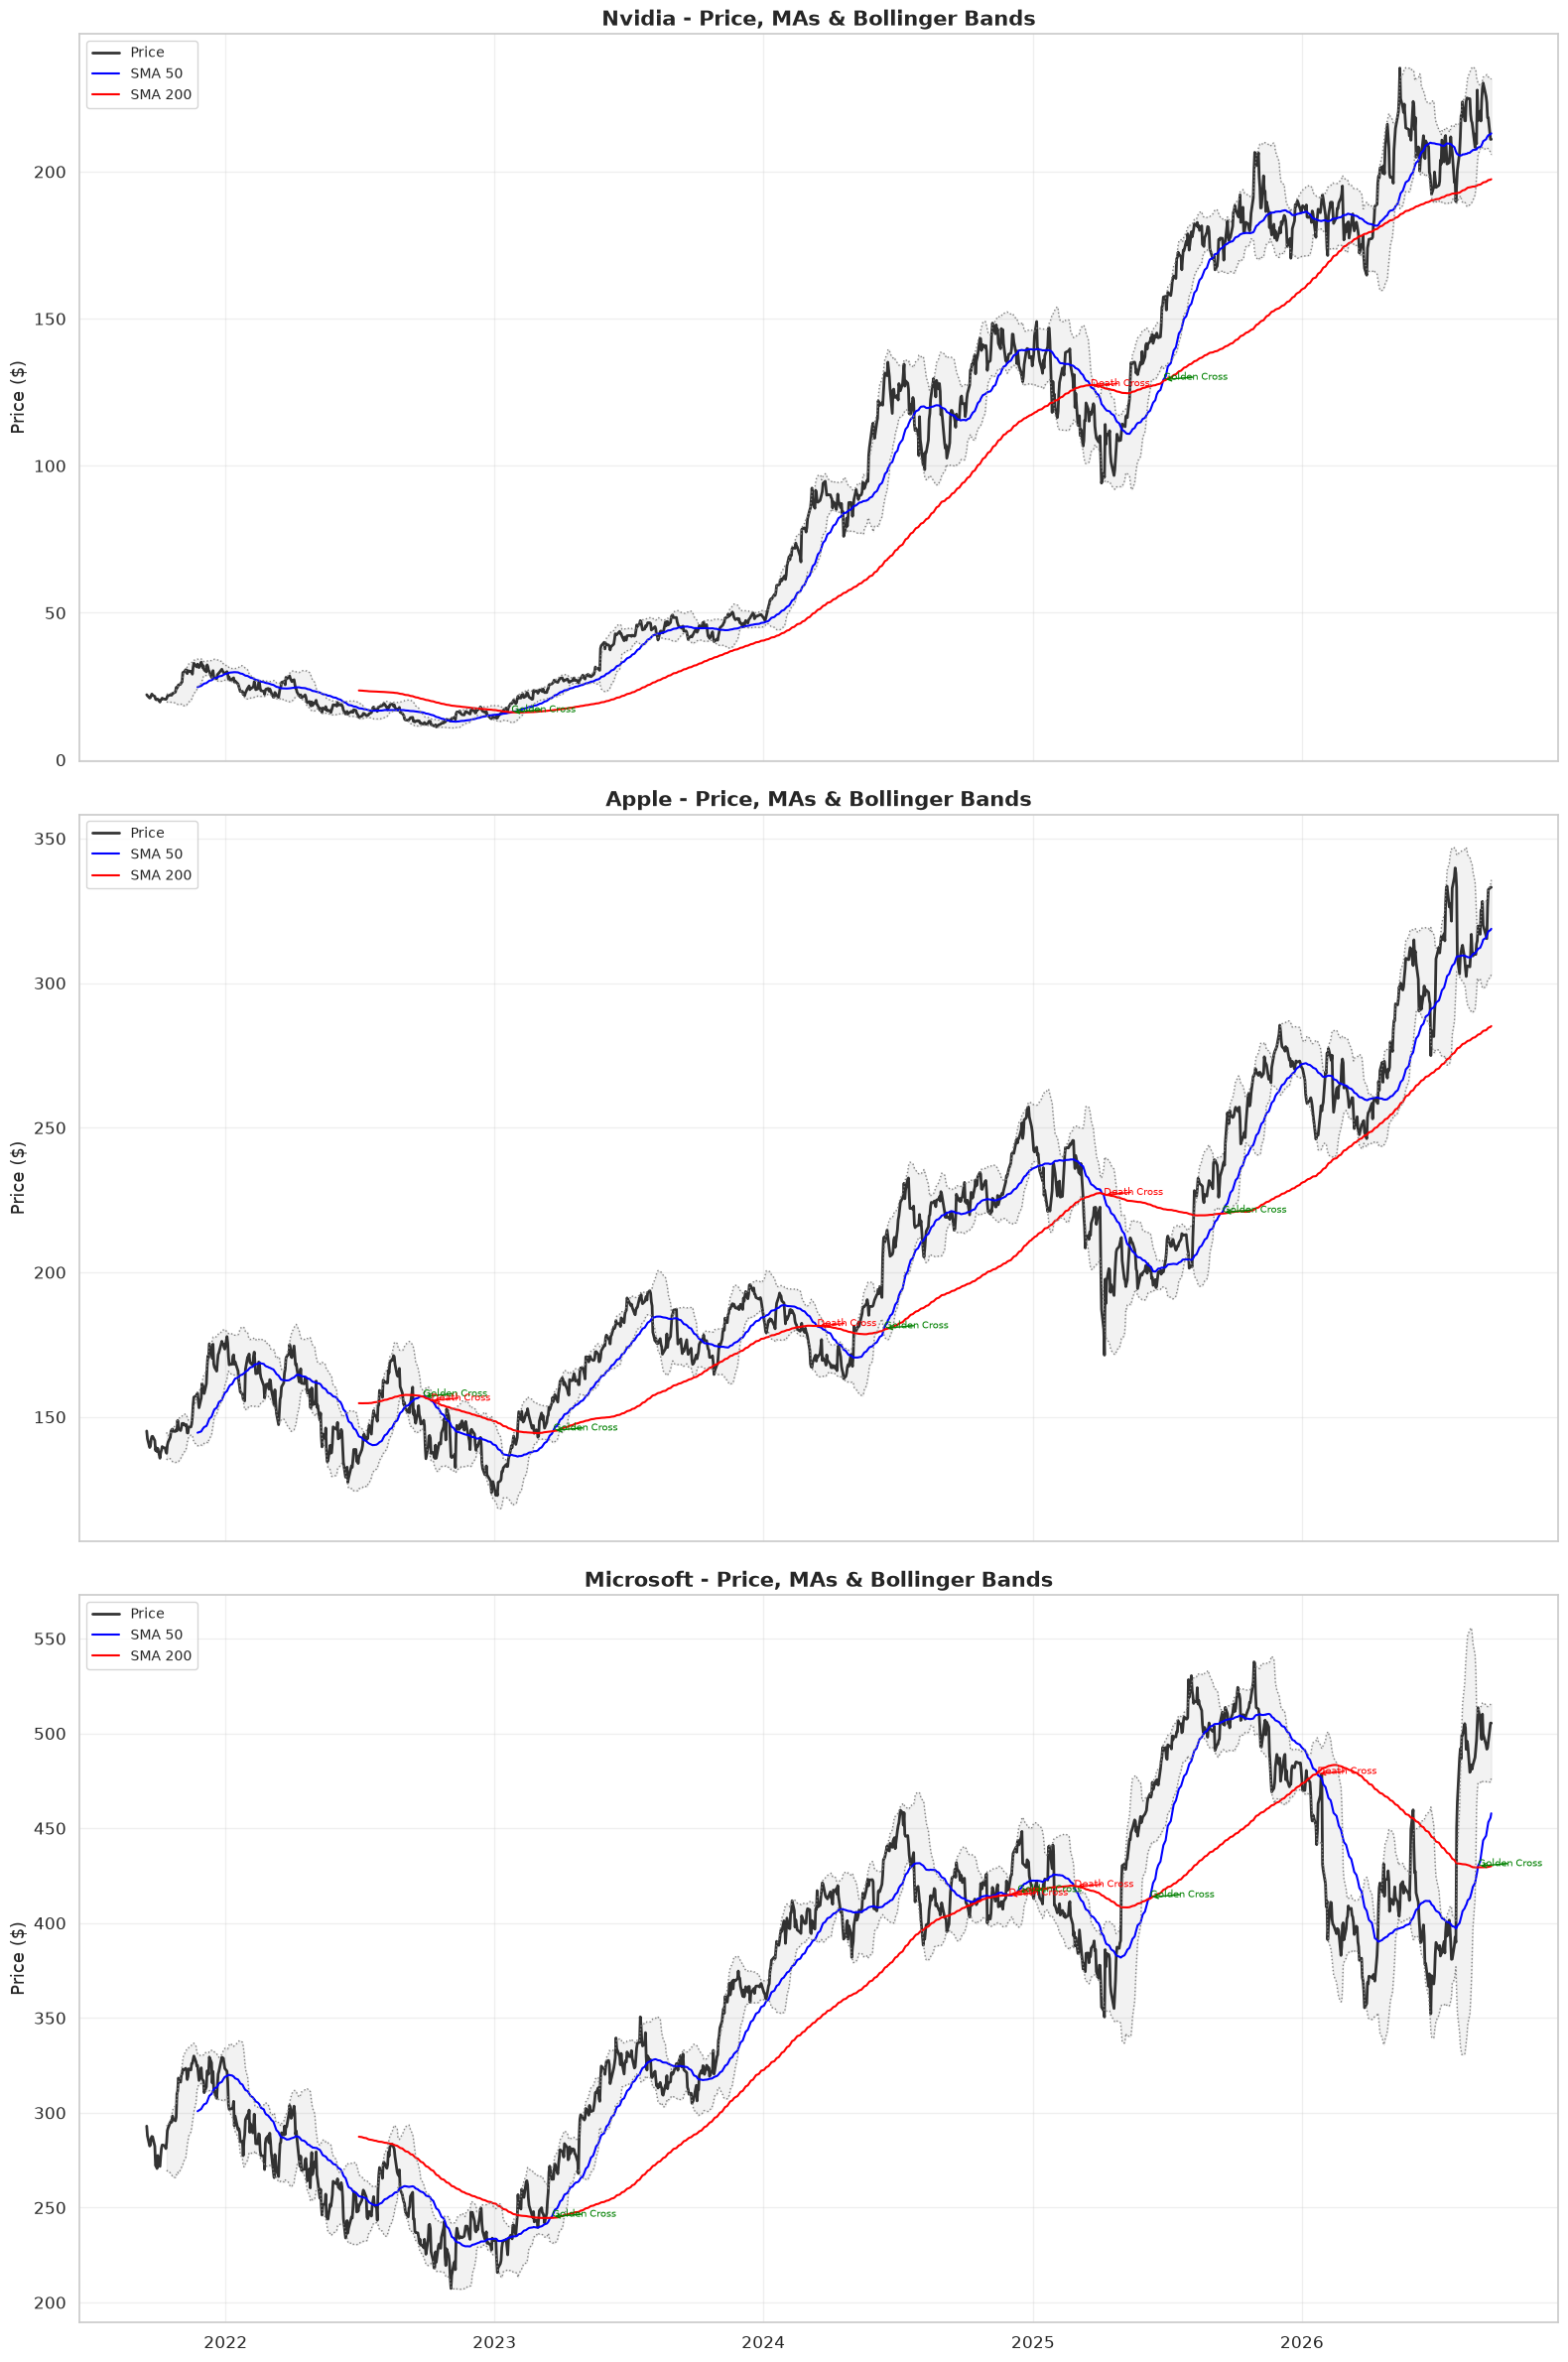

✓ Saved: technical_analysis_price.png


In [9]:
tech_stocks = ['BRK-B', 'JPM', 'PFE']

fig, axes = plt.subplots(len(tech_stocks), 1, figsize=(16, 24), sharex=True)

for idx, ticker in enumerate(tech_stocks):
    ax = axes[idx]
    price = close[ticker]
    sma_50 = price.rolling(50).mean()
    sma_200 = price.rolling(200).mean()
    bb_mid = price.rolling(20).mean()
    bb_std = price.rolling(20).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std

    ax.plot(price.index, price, label='Price', color='black', linewidth=2, alpha=0.8)
    ax.plot(price.index, sma_50, label='SMA 50', color='blue', linewidth=1.5)
    ax.plot(price.index, sma_200, label='SMA 200', color='red', linewidth=1.5)
    ax.fill_between(price.index, bb_upper, bb_lower, alpha=0.1, color='gray')
    ax.plot(price.index, bb_upper, color='gray', linestyle=':', linewidth=1)
    ax.plot(price.index, bb_lower, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{STOCKS[ticker]} - Price, MAs & Bollinger Bands', fontsize=15, fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    golden = (sma_50 > sma_200) & (sma_50.shift(1) <= sma_200.shift(1))
    for date in golden.index[golden]:
        if pd.notna(sma_50.loc[date]):
            ax.annotate('Golden Cross', xy=(date, sma_50.loc[date]), fontsize=7, color='green',
                       arrowprops=dict(arrowstyle='->', color='green'))
    death = (sma_50 < sma_200) & (sma_50.shift(1) >= sma_200.shift(1))
    for date in death.index[death]:
        if pd.notna(sma_50.loc[date]):
            ax.annotate('Death Cross', xy=(date, sma_50.loc[date]), fontsize=7, color='red',
                       arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('technical_analysis_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: technical_analysis_price.png")


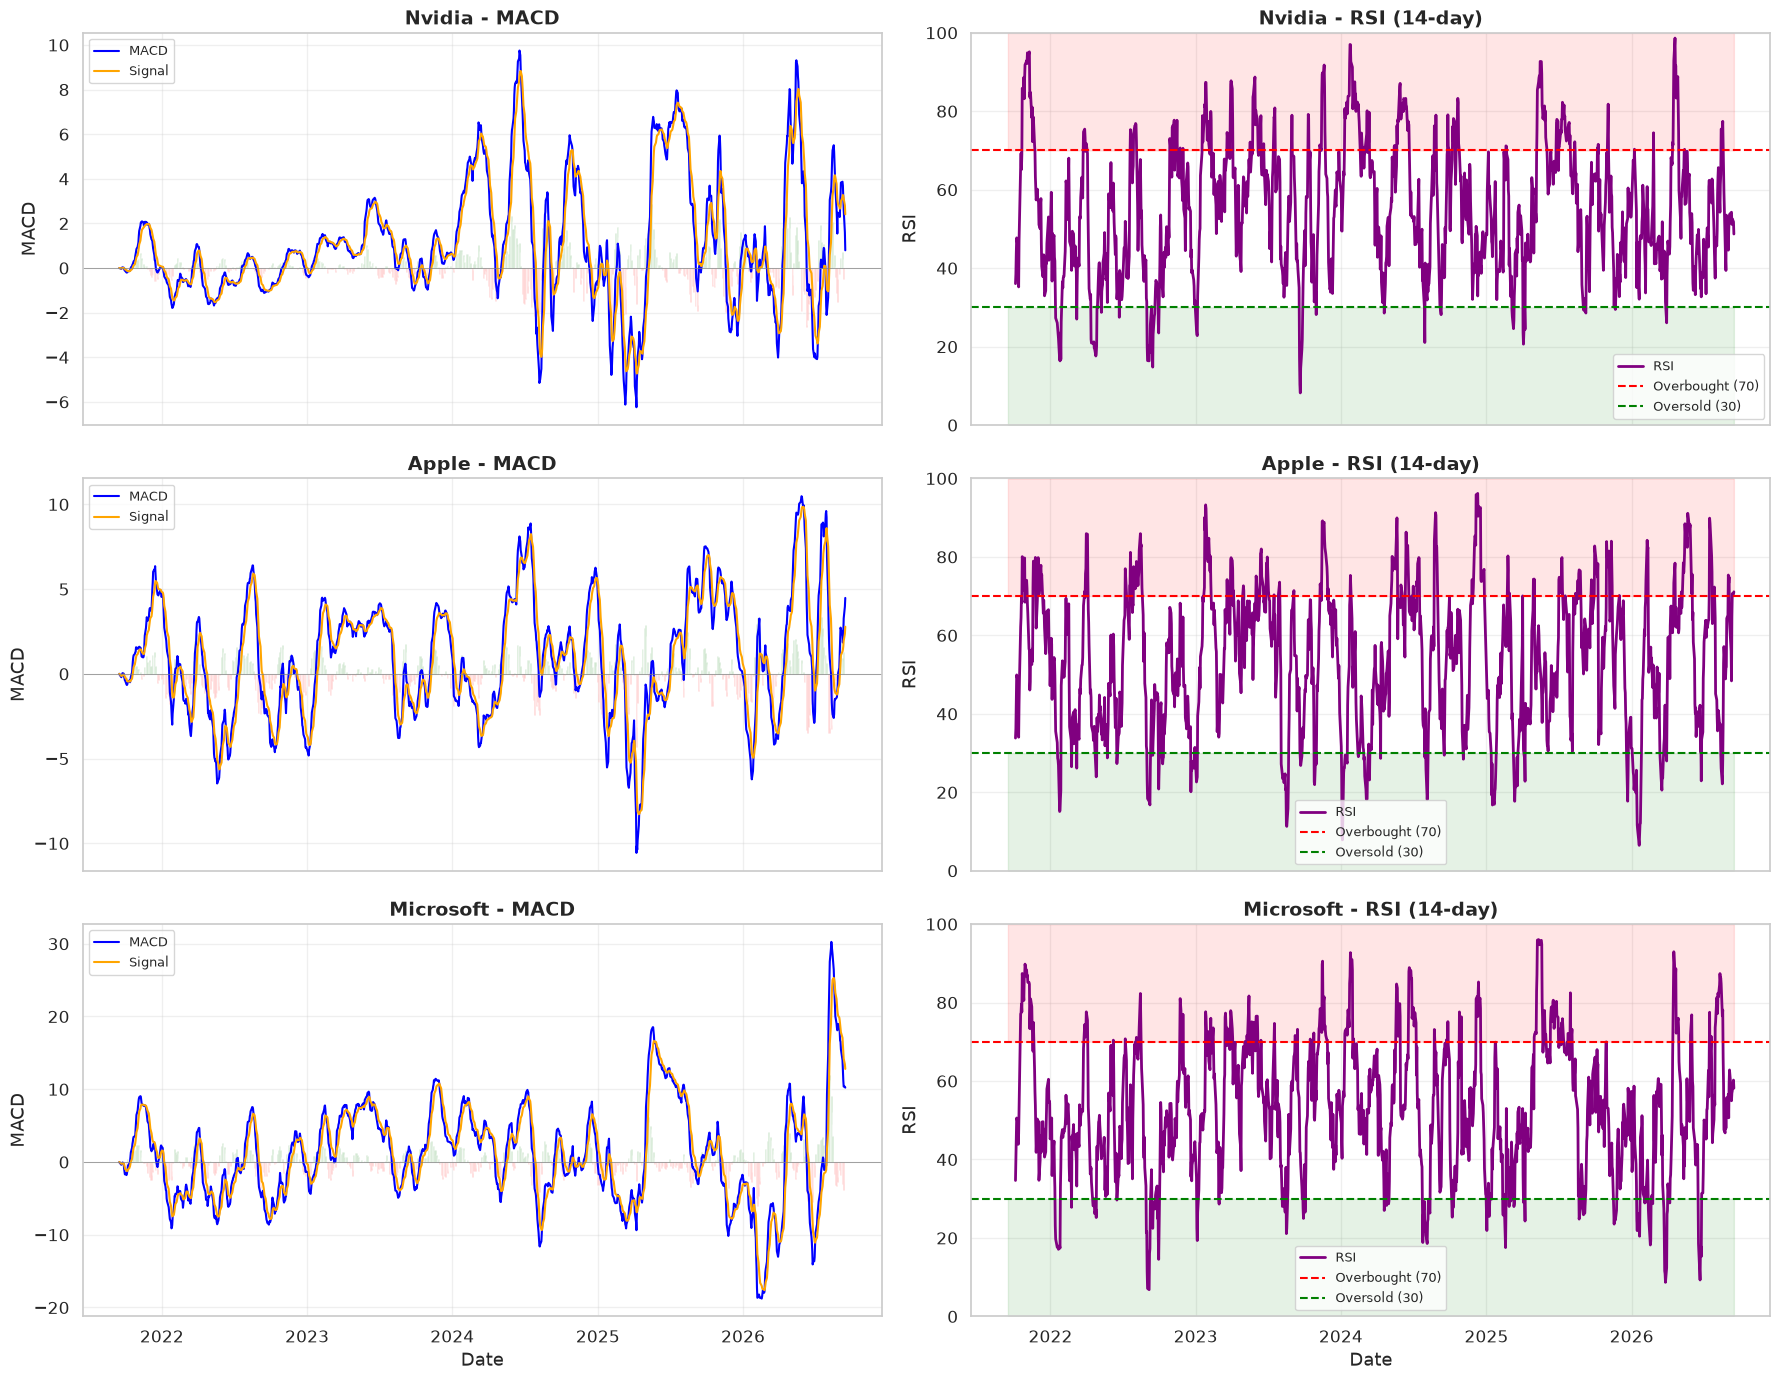

✓ Saved: technical_indicators_macd_rsi.png


In [10]:
fig, axes = plt.subplots(len(tech_stocks), 2, figsize=(18, 14), sharex=True)

for idx, ticker in enumerate(tech_stocks):
    price = close[ticker]
    ema_12 = price.ewm(span=12).mean()
    ema_26 = price.ewm(span=26).mean()
    macd = ema_12 - ema_26
    macd_signal = macd.ewm(span=9).mean()
    macd_histogram = macd - macd_signal

    delta = price.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    # FIX: Use np.where for array colors, NOT `macd_histogram.values > 0` which raises ValueError
    ax1 = axes[idx, 0]
    bar_colors = np.where(macd_histogram.values > 0, 'green', 'red')
    ax1.bar(macd_histogram.index, macd_histogram.values, color=bar_colors, alpha=0.4, width=1)
    ax1.plot(macd.index, macd.values, label='MACD', color='blue', linewidth=1.5)
    ax1.plot(macd_signal.index, macd_signal.values, label='Signal', color='orange', linewidth=1.5)
    ax1.axhline(y=0, color='gray', linewidth=0.5)
    ax1.set_title(f'{STOCKS[ticker]} - MACD', fontsize=14, fontweight='bold')
    ax1.set_ylabel('MACD')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[idx, 1]
    ax2.plot(rsi.index, rsi.values, label='RSI', color='purple', linewidth=2)
    ax2.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
    ax2.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
    ax2.fill_between(rsi.index, 70, 100, alpha=0.1, color='red')
    ax2.fill_between(rsi.index, 0, 30, alpha=0.1, color='green')
    ax2.set_title(f'{STOCKS[ticker]} - RSI (14-day)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('RSI')
    ax2.set_ylim(0, 100)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('technical_indicators_macd_rsi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: technical_indicators_macd_rsi.png")


---
## 💼 Section 5: Portfolio Analysis


In [11]:
weights = {t: 1/len(non_spy) for t in non_spy}
portfolio_returns = sum(daily_returns[t] * w for t, w in weights.items())

portfolio_ann_return = portfolio_returns.mean() * TRADING_DAYS
portfolio_ann_vol = portfolio_returns.std() * np.sqrt(TRADING_DAYS)
portfolio_sharpe = (portfolio_ann_return - RISK_FREE_RATE) / portfolio_ann_vol
portfolio_max_dd = calculate_max_drawdown((1 + portfolio_returns).cumprod())

spy_returns = daily_returns['SPY']
spy_ann_return = spy_returns.mean() * TRADING_DAYS
spy_ann_vol = spy_returns.std() * np.sqrt(TRADING_DAYS)
spy_sharpe = (spy_ann_return - RISK_FREE_RATE) / spy_ann_vol
spy_max_dd = calculate_max_drawdown((1 + spy_returns).cumprod())

avg_individual_vol = annualized_volatility[non_spy].mean()
diversification_benefit = ((avg_individual_vol - portfolio_ann_vol) / avg_individual_vol) * 100

print("="*90)
print("💼 PORTFOLIO vs BENCHMARK")
print("="*90)
print(f"{'Metric':<25s} {'Portfolio':>20s} {'SPY':>15s} {'Diff':>10s}")
print("-" * 75)
print(f"{'Annualized Return':<25s} {portfolio_ann_return:>19.1%} {spy_ann_return:>14.1%} {portfolio_ann_return-spy_ann_return:>+9.1%}")
print(f"{'Volatility':<25s} {portfolio_ann_vol:>19.1%} {spy_ann_vol:>14.1%} {portfolio_ann_vol-spy_ann_vol:>+9.1%}")
print(f"{'Sharpe Ratio':<25s} {portfolio_sharpe:>20.2f} {spy_sharpe:>15.2f} {portfolio_sharpe-spy_sharpe:>+9.2f}")
print(f"{'Max Drawdown':<25s} {portfolio_max_dd:>19.1%} {spy_max_dd:>14.1%} {portfolio_max_dd-spy_max_dd:>+9.1%}")
print(f"\n🔗 Diversification Benefit: {diversification_benefit:.1f}% lower volatility")


💼 PORTFOLIO vs BENCHMARK
Metric                               Portfolio             SPY       Diff
---------------------------------------------------------------------------
Annualized Return                       29.2%          13.5%    +15.7%
Volatility                              29.7%          17.2%    +12.5%
Sharpe Ratio                              0.83            0.52     +0.31
Max Drawdown                           -45.5%         -24.5%    -21.0%

🔗 Diversification Benefit: 26.6% lower volatility


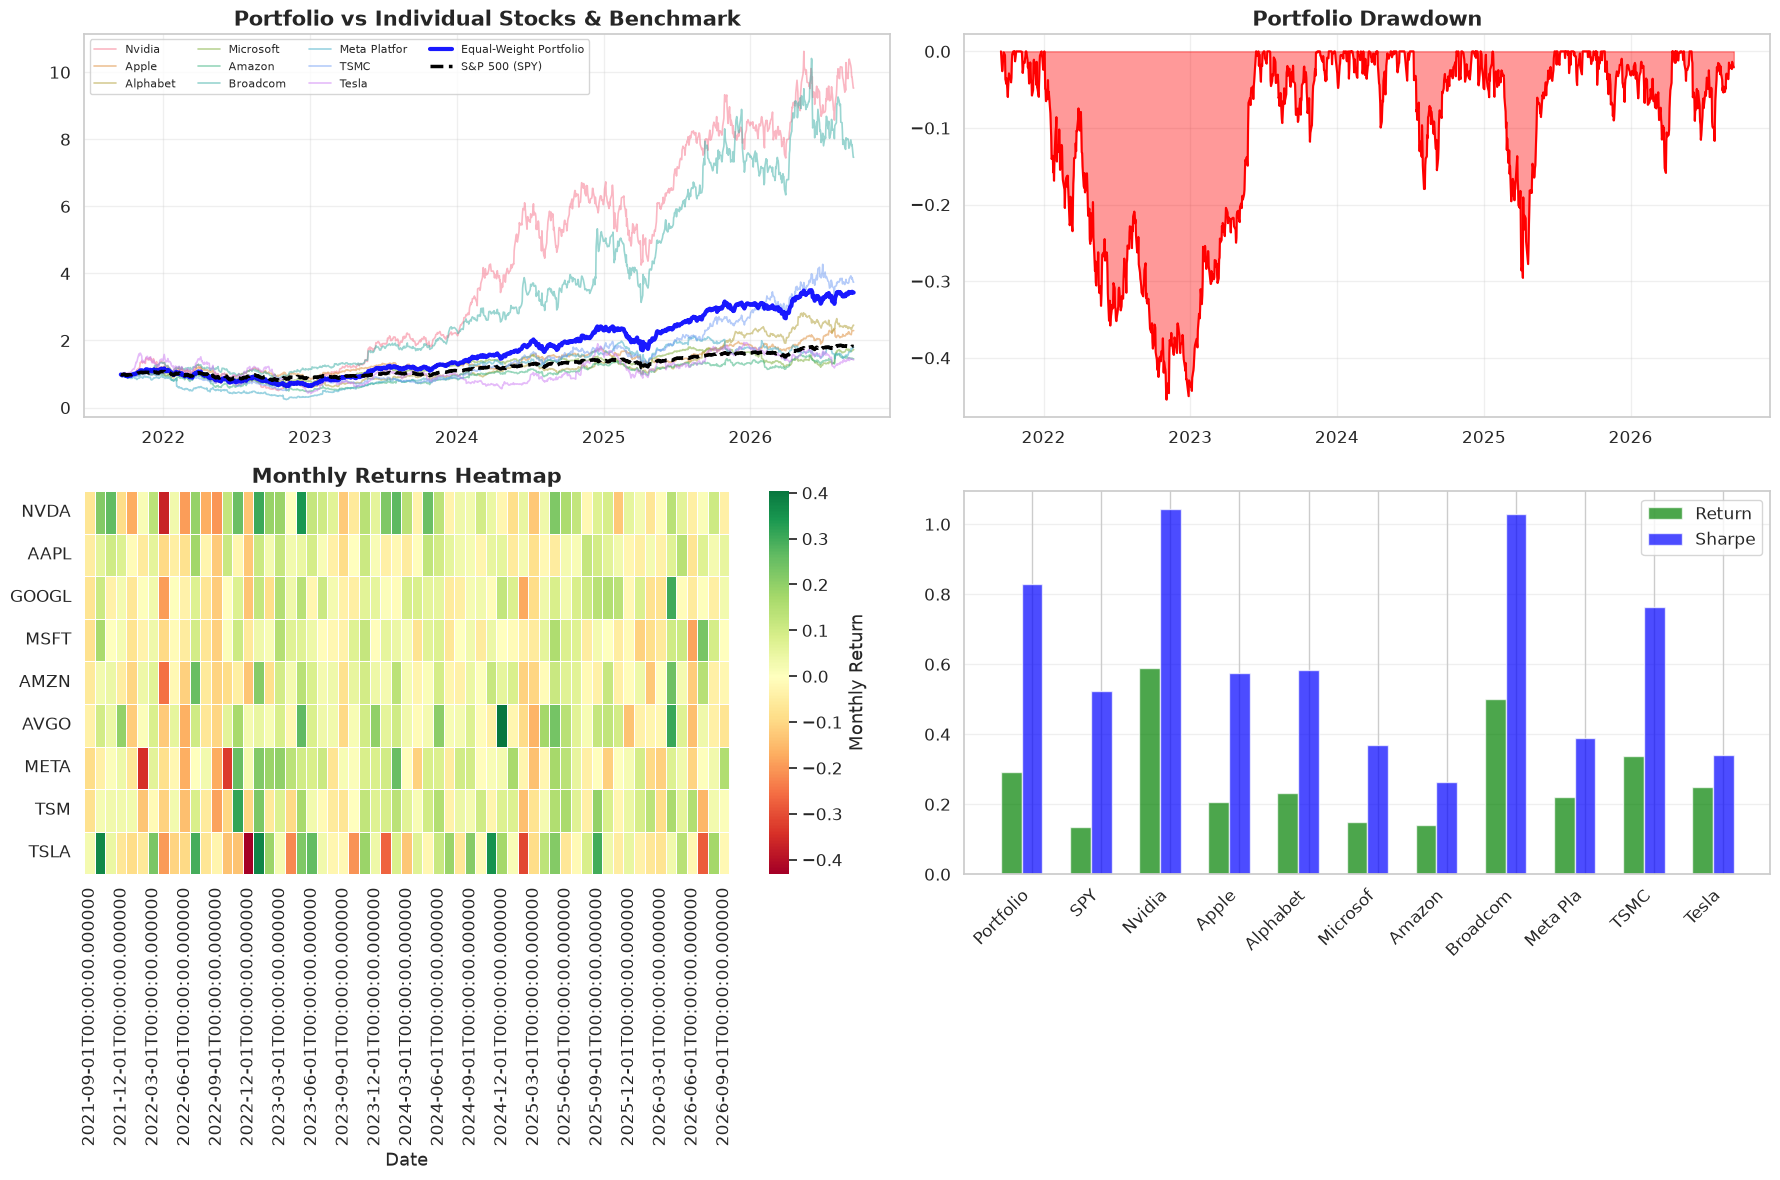

✓ Saved: portfolio_analysis.png


In [12]:
portfolio_cum = (1 + portfolio_returns).cumprod()
spy_cum = (1 + spy_returns).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
for i, ticker in enumerate(non_spy):
    ax.plot((1+daily_returns[ticker]).cumprod().index, (1+daily_returns[ticker]).cumprod(),
           label=STOCKS[ticker][:12], color=COLORS[i], linewidth=1.2, alpha=0.5)
ax.plot(portfolio_cum.index, portfolio_cum, label='Equal-Weight Portfolio', color='blue', linewidth=3, alpha=0.9, zorder=5)
ax.plot(spy_cum.index, spy_cum, label='S&P 500 (SPY)', color='black', linewidth=2.5, linestyle='--', zorder=5)
ax.set_title('Portfolio vs Individual Stocks & Benchmark', fontsize=15, fontweight='bold')
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
portfolio_dd = ((portfolio_cum - portfolio_cum.expanding().max()) / portfolio_cum.expanding().max())
ax.fill_between(portfolio_dd.index, portfolio_dd.values, 0, color='red', alpha=0.4)
ax.plot(portfolio_dd.index, portfolio_dd.values, color='red', linewidth=1.5)
ax.set_title('Portfolio Drawdown', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
monthly_ret = daily_returns[non_spy].groupby(daily_returns.index.to_period('M')).sum()
monthly_ret.index = monthly_ret.index.to_timestamp()
sns.heatmap(monthly_ret.T, cmap='RdYlGn', center=0, fmt='.0%', linewidths=0.5, cbar_kws={'label': 'Monthly Return'}, ax=ax)
ax.set_title('Monthly Returns Heatmap', fontsize=15, fontweight='bold')

ax = axes[1, 1]
comp_df = pd.DataFrame({
    'Return': [portfolio_ann_return, spy_ann_return] + annualized_returns[non_spy].tolist(),
    'Sharpe': [portfolio_sharpe, spy_sharpe] + sharpe_ratios[non_spy].tolist()
}, index=['Portfolio', 'SPY'] + [STOCKS[t][:8] for t in non_spy])
x = np.arange(len(comp_df))
width = 0.3
ax.bar(x-width, comp_df['Return'], width, label='Return', color='green', alpha=0.7)
ax.bar(x, comp_df['Sharpe'], width, label='Sharpe', color='blue', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('portfolio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: portfolio_analysis.png")


---
## 🎛️ Section 6: Interactive Dashboard (Plotly)


In [13]:
import plotly.express as px

# Use a Plotly qualitative color sequence
COLORS = px.colors.qualitative.Plotly  # Returns a list of hex strings

fig = go.Figure()
for i, ticker in enumerate(tickers):
    fig.add_trace(go.Scatter(
        x=close.index, 
        y=close[ticker], 
        name=STOCKS[ticker],
        line=dict(color=COLORS[i % len(COLORS)], width=2),
        hovertemplate=f'<b>{STOCKS[ticker]}</b><br>Date: %{{x}}<br>Price: $%{{y:.2f}}<extra></extra>'
    ))

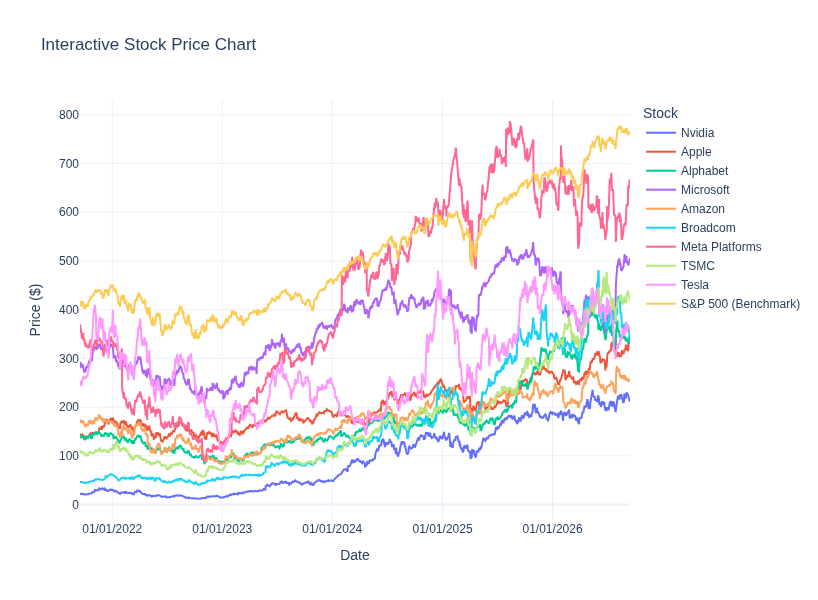

✓ Saved: interactive_price_chart.html


In [14]:
import plotly.express as px
import plotly.graph_objects as go

# Retrieve Plotly's default qualitative hex color palette
COLORS = px.colors.qualitative.Plotly

fig = go.Figure()

for i, ticker in enumerate(tickers):
    fig.add_trace(
        go.Scatter(
            x=close.index,
            y=close[ticker],
            name=STOCKS[ticker],
            line=dict(color=COLORS[i % len(COLORS)], width=2),
            hovertemplate=f"<b>{STOCKS[ticker]}</b><br>Date: %{{x}}<br>Price: $%{{y:.2f}}<extra></extra>",
        )
    )

fig.update_layout(
    title="Interactive Stock Price Chart",
    xaxis_title="Date",
    yaxis_title="Price ($)",
    hovermode="x unified",
    legend_title="Stock",
    height=600,
    template="plotly_white",
)

# Format the x-axis dates using standard D3 date formatting
fig.update_xaxes(tickformat="%m/%d/%Y")

fig.write_html("interactive_price_chart.html")
fig.show()

print("✓ Saved: interactive_price_chart.html")

---
## 📋 Executive Summary


In [15]:
ranked_ret = sorted(non_spy, key=lambda x: annualized_returns[x], reverse=True)
ranked_sharpe = sorted(non_spy, key=lambda x: sharpe_ratios[x], reverse=True)
ranked_vol = sorted(non_spy, key=lambda x: annualized_volatility[x])

print("="*90)
print("📋 EXECUTIVE SUMMARY & KEY TAKEAWAYS")
print("="*90)
print()
print("🏆 By Annualized Return:")
for i, t in enumerate(ranked_ret, 1):
    print(f"  {i}. {STOCKS[t]:<25s} {annualized_returns[t]:>8.1%}")
print()
print("🏆 By Sharpe Ratio:")
for i, t in enumerate(ranked_sharpe, 1):
    print(f"  {i}. {STOCKS[t]:<25s} {sharpe_ratios[t]:>8.2f}")
print()
print("💡 KEY TAKEAWAYS:")
print(f"1. 🚀 {STOCKS[ranked_ret[0]]} led returns at {annualized_returns[ranked_ret[0]]:.1f}%")
print(f"2. 🛡️  {STOCKS[ranked_vol[0]]} was least volatile at {annualized_volatility[ranked_vol[0]]:.1f}%")
print(f"3. ⚖️  {STOCKS[ranked_sharpe[0]]} best risk-adjusted (Sharpe: {sharpe_ratios[ranked_sharpe[0]]:.2f})")
print(f"4. 📊 Portfolio Sharpe {portfolio_sharpe:.2f} vs SPY {spy_sharpe:.2f}")
print(f"5. 💰 Diversification benefit: {diversification_benefit:.1f}% lower volatility")
print()
print("⚠️  Disclaimer: For educational purposes only. Not investment advice.")
print("="*90)
print("✅ Analysis Complete!")
print("="*90)


📋 EXECUTIVE SUMMARY & KEY TAKEAWAYS

🏆 By Annualized Return:
  1. Nvidia                       58.8%
  2. Broadcom                     50.2%
  3. TSMC                         33.9%
  4. Tesla                        25.0%
  5. Alphabet                     23.2%
  6. Meta Platforms               22.1%
  7. Apple                        20.6%
  8. Microsoft                    14.9%
  9. Amazon                       14.1%

🏆 By Sharpe Ratio:
  1. Nvidia                        1.04
  2. Broadcom                      1.03
  3. TSMC                          0.76
  4. Alphabet                      0.58
  5. Apple                         0.57
  6. Meta Platforms                0.39
  7. Microsoft                     0.37
  8. Tesla                         0.34
  9. Amazon                        0.26

💡 KEY TAKEAWAYS:
1. 🚀 Nvidia led returns at 0.6%
2. 🛡️  Apple was least volatile at 0.3%
3. ⚖️  Nvidia best risk-adjusted (Sharpe: 1.04)
4. 📊 Portfolio Sharpe 0.83 vs SPY 0.52
5. 💰 Diversification b